In [ ]:
import xarray as xr
import pandas as pd
import rioxarray
import numpy as np
from rasterio.enums import Resampling 
import matplotlib

import matplotlib.pyplot as plt


from pathlib import Path
import geopandas as gpd

from sklearn.metrics import mean_squared_error, r2_score
import os
import gc

root = Path.cwd()

def get_coverage(pred_raster,lidar_raster,block_map_array):
    total_city_valid = pred_raster.notnull().sum().item()
    lidar_valid = lidar_raster.notnull().sum().item()
    pct_of_city_valid = np.round((total_city_valid/lidar_valid)*100,2)


    test_pixels = block_map_array.where(block_map_array==1).sum().item()
    test_pct = np.round((test_pixels/lidar_valid)*100,2)

    print(f'Percent of city area predicted: {pct_of_city_valid}%')
    print(f'Percent of city covered by test blocks: {test_pct}%')

def bias_barplot(y_test,resids):

    abs_resids = np.abs(resids)
    total_pixels = len(abs_resids)
    bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
    bin_labels = [f'{b}-{bins[i+1]}' for i, b in enumerate(bins[:-1])]
    bin_ids = pd.cut(y_test, bins=bins, labels=bin_labels)

    bin_stats = pd.DataFrame({
        'residual': resids,
        'abs_residual': abs_resids,
        'bin': bin_ids
    }).groupby('bin').agg(
        mean_bias=('residual', 'mean'),
        rmse=('residual', lambda x: np.sqrt(np.mean(x**2))),
        count=('residual', 'count')
    ).reset_index()

    bin_stats['pct'] = (bin_stats['count']/total_pixels)*100
    print(bin_stats)

    # # Plot bias by bin
    fig, axes = plt.subplots(1,2,figsize=(10,5))

    axes[0].bar(bin_stats['bin'], bin_stats['mean_bias'])
    axes[0].axhline(0, color='red', linewidth=1)
    axes[0].set_xlabel('Actual Canopy % Bin')
    axes[0].set_ylabel('Mean Residual')
    axes[0].set_title('Mean Residual by Canopy Cover')
    axes[0].tick_params(axis='x', rotation=45)

    axes[1].bar(bin_stats['bin'], bin_stats['pct'])
    axes[1].axhline(0, color='red', linewidth=1)
    axes[1].set_xlabel('Actual Canopy % Bin')
    axes[1].set_ylabel('Percent of Total')
    axes[1].set_title('Canopy Cover Prevalance')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()


def increasing_scale_lineplot(scale_df):
    fig, ax1 = plt.subplots(figsize=(8,5))

    ax1.plot(scale_df['res'],scale_df['rmse'],marker='o',color='steelblue',label='RMSE')
    ax1.set_ylabel('RMSE',color='steelblue')
    ax1.tick_params(axis='y',labelcolor='steelblue')

    ax2 = ax1.twinx()
    ax2.plot(scale_df['res'],scale_df['r2'],marker='o',color='darkorange',label='R2')
    ax2.set_ylabel('R2',color='darkorange')
    ax2.tick_params(axis='y',labelcolor='darkorange')

    ax1.set_xlabel('Pixel Resolution (m)')
    ax1.set_title('Performance at Increasing Spatial Scales')

    plt.show()



def resample_predictions(pred_raster,lidar_raster,block_map_array,rmse_10m,r2_10m,scales):

    crs_ob = pred_raster.rio.crs
    rmse_list = [rmse_10m]
    r2_list = [r2_10m]
    
    for i in scales[1:]:
      
        lidar_coarse = lidar_raster.rio.reproject(crs_ob,resolution=i,resampling=Resampling.average)
        pred_coarse = pred_raster.rio.reproject(crs_ob,resolution=i,resampling=Resampling.average)

        block_map_coarse = block_map_array.rio.reproject(crs_ob,resolution=i,resampling=Resampling.nearest)

        valid_preds = pred_raster.notnull().astype(int)
        valid_fraction = valid_preds.rio.reproject(crs_ob,resolution=i,resampling=Resampling.average)
        coverage_mask = valid_fraction >= 0.8

        pred_test_blocks = pred_coarse.where((block_map_coarse==1)&coverage_mask)
        lidar_test_blocks = lidar_coarse.where((block_map_coarse==1)&coverage_mask)

        pred_flat = pred_test_blocks.values.flatten()
        lidar_flat = lidar_test_blocks.values.flatten()

        valid = np.isfinite(pred_flat) & np.isfinite(lidar_flat)

        rmse = np.sqrt(mean_squared_error(lidar_flat[valid],pred_flat[valid]))
        r2 = r2_score(lidar_flat[valid],pred_flat[valid])

        rmse_list.append(np.round(rmse,2))
        r2_list.append(np.round(r2,2))

    out_df = pd.DataFrame({'res':scales,'rmse':rmse_list,'r2':r2_list})

    return out_df


In [ ]:
## read in data
siteyear = 'nyc18'
model_siteyear = 'nyc18'
lidar_raster = rioxarray.open_rasterio(root/ 'data' / siteyear / f'{siteyear}_tree_canopy_lidar.tif').squeeze('band',drop=True)
pred_raster = rioxarray.open_rasterio(root / 'model_outputs' / f'{siteyear}_canopy_percent.tif' ).squeeze('band',drop=True)
pred_raster = pred_raster.rio.write_crs(26918).rio.set_spatial_dims(x_dim='x',y_dim='y').rio.write_coordinate_system()

# crop lidar to match boundaries
b = gpd.read_file(root / 'data' / 'nyc_boundary.gpkg')
lidar_cropped = lidar_raster.rio.clip(b.geometry)

# mask for rmse calculation
lidar_masked = lidar_raster.where(pred_raster.notnull())

## block map to get test blocks for evaluation
## train = 0, test = 1
block_map = np.load(root / 'data' / 'nyc21' / 'train_test_blocks.npz')
block_map = block_map['arr_0']

block_map_array = xr.DataArray(block_map,dims=['y','x'],coords={'x':pred_raster.coords['x'],'y':pred_raster.coords['y']})
block_map_array = block_map_array.rio.write_crs(26918).rio.set_spatial_dims(x_dim='x',y_dim='y').rio.write_coordinate_system()

get_coverage(pred_raster=pred_raster,lidar_raster=lidar_cropped,block_map_array=block_map_array)

# Percent of city covered by test blocks: 47.78%

# 2021:
# Percent of city area predicted: 97.11%

# 2017
#Percent of city area predicted: 91.93%

Percent of city area predicted: 97.11%
Percent of city covered by test blocks: 47.78%


Index(['boro_name', 'geometry'], dtype='str')

In [ ]:
from exactextract import exact_extract 

b = b.drop(columns=['boro_code','shape_area','shape_leng'])
b.columns

bb = b.union_all()

bb_gdf = gpd.GeoDataFrame({'boro_name':'city'},geometry=[bb],index=[0],crs=b.crs)

bounds = pd.concat([b,bb_gdf])

valid_mask = pred_raster.notnull()
lidar_masked = lidar_raster.where(valid_mask)
pred_stats = exact_extract(pred_raster,bounds,'mean(min_coverage_frac=0.5)',include_cols=['boro_name'],output='pandas')
pred_stats = pred_stats.rename(columns={'mean':'pred_mean'})
lidar_stats = exact_extract(lidar_masked,bounds,'mean(min_coverage_frac=0.5)',include_cols=['boro_name'],output='pandas')

In [62]:
stats_21 = lidar_stats.merge(pred_stats,on='boro_name')
stats_21

,boro_name,mean,pred_mean
0,Bronx,27.191176,26.688403
1,Staten Island,33.941475,34.126005
2,Brooklyn,19.898988,18.995862
3,Queens,20.041480,19.982209
4,Manhattan,23.742440,21.074135
5,city,23.982403,23.522514


In [64]:
stats17 = pd.read_csv(root / 'model_outputs' / 'nyc17_perboro.csv')
stats17

,Unnamed: 0,boro_name,mean,pred_mean
0,0,Bronx,25.985989,26.021748
1,1,Staten Island,32.221952,32.436703
2,2,Brooklyn,17.810969,16.197209
3,3,Queens,19.798303,19.457743
4,4,Manhattan,22.656596,19.592378
5,5,city,23.011959,22.367134


#### RMSE at 10m resolution

In [ ]:
pred_test_blocks = pred_raster.where(block_map==1)
lidar_test_blocks = lidar_masked.where(block_map==1)

pred_flat = pred_test_blocks.values.flatten()
lidar_flat = lidar_test_blocks.values.flatten()

valid = np.isfinite(pred_flat) & np.isfinite(lidar_flat)

rmse = np.sqrt(mean_squared_error(lidar_flat[valid],pred_flat[valid]))
r2 = r2_score(lidar_flat[valid],pred_flat[valid])

resids = pred_flat[valid] - lidar_flat[valid] 

# 2021
# r2 = 0.7882870101544974
# rmse = 15.442492093656925

#2017
# rmse: 16.66838481947889
# r2: 0.7460536956787109


## 2021 model to predict 2017:rmse: 31.731651471017468, r2: 0.0796772241592407
## reasons for poor 2021 -> 2017 performance:
# 2021 had more data coverage, especially in spring, the most phenologically important period (4 vs 13 acquisition dates)
## therefore all of the most important variables in the 2021 model are extremely noisy in the 2017 data. 
# the model was able to learn more precise relationships that don't actually exist in the 2017 data. 
# in contrast, the 2017 data was noisier. the relationships it learned from its sparse data were also present in the 2021 data. 

## 2017 model to predict 2021: rmse: 21.117049487386595, r2: 0.6041075587272644

print(f'rmse: {rmse}, r2: {r2}')

rmse: 31.731651471017468, r2: 0.07967722415924072


In [ ]:
bias_barplot(lidar_flat[valid],resids)

#### Aggregate to larger spatial scales

In [20]:
scales = [10,20,30,60,90,120,150,180,200]
scale_df = resample_predictions(pred_raster=pred_raster,lidar_raster=lidar_raster,rmse_10m=rmse,r2_10m=r2,block_map_array=block_map_array,scales=scales)

In [21]:
scale_df

,res,rmse,r2
0,10,31.731651,0.079677
1,20,27.520000,0.070000
2,30,25.220000,0.040000
3,60,22.530000,-0.030000
4,90,21.510000,-0.100000
5,120,20.900000,-0.140000
6,150,20.350000,-0.170000
7,180,20.180000,-0.210000
8,200,19.850000,-0.240000


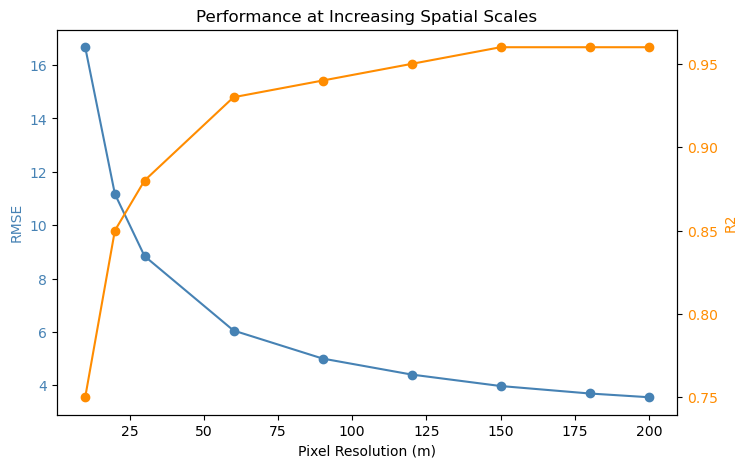

In [20]:
increasing_scale_lineplot(scale_df)

#### Aggregate to political boundaries

In [1]:
import xarray as xr
import pandas as pd
import rioxarray
import numpy as np
from rasterio.enums import Resampling 
import matplotlib

import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
from sklearn.metrics import r2_score, mean_squared_error

from pathlib import Path
import geopandas as gpd
from exactextract import exact_extract 
from matplotlib.patches import Patch


root = Path.cwd()

def plot_low_coverage(nta_stats,cd_stats,nta_min,cd_min):
    fig, axes = plt.subplots(1,2,figsize=(8,5))
    nta_stats.plot(ax=axes[0],color='white',edgecolor='black',linewidth=.3)
    nta_stats.loc[(nta_stats['coverage']<=(nta_min/100))].plot(ax=axes[0],color='red')
    axes[0].set_axis_off()
    axes[0].legend(handles=[Patch(facecolor='red', label=f'<{nta_min}% coverage')],loc='upper left')
    axes[0].set_title('Neighborhood Tabulation Areas')

    cd_stats.plot(ax=axes[1],color='white',edgecolor='black',linewidth=.3)
    cd_stats.loc[(cd_stats['coverage']<=(cd_min/100))].plot(ax=axes[1],color='red')
    axes[1].legend(handles=[Patch(facecolor='red', label=f'<{cd_min}% coverage')],loc='upper left')
    axes[1].set_axis_off()
    axes[1].set_title('Community Districts')

    plt.tight_layout()
    plt.show()

## mean canopy per NTa
# exclude NAN pixels
# include pixels with >50% coverage by polygon
def aggregate_to_polys(pred_raster,lidar_raster,polys):

    gdf = polys.copy()

    valid_mask = pred_raster.notnull()
    lidar_masked = lidar_raster.where(valid_mask)
    pred_stats = exact_extract(pred_raster,gdf,'mean(min_coverage_frac=0.5)',output='pandas')
    lidar_stats = exact_extract(lidar_masked,gdf,'mean(min_coverage_frac=0.5)',output='pandas')
    coverage_stats = exact_extract(valid_mask,gdf,'mean',output='pandas')

    gdf['predicted_pct'] = pred_stats['mean']
    gdf['lidar_pct'] = lidar_stats['mean']
    gdf['coverage'] = coverage_stats['mean']

    if 'borocd' in gdf.columns:
        name_col = 'borocd'
    else:
        name_col = 'ntaname2020'

    stats = gdf[['geometry','predicted_pct','lidar_pct','coverage',name_col]]
    stats['residual'] = stats['predicted_pct'] - stats['lidar_pct']

    return stats

def predicted_v_actual(gdf,min_coverage):
    
    gdf_plot = gdf.loc[(gdf['coverage']>=min_coverage)]

    rmse = np.sqrt(mean_squared_error(gdf_plot['lidar_pct'],gdf_plot['predicted_pct']))
    r2 = r2_score(gdf_plot['lidar_pct'],gdf_plot['predicted_pct'])
    #spearman_r, spearman_p = scipy_stats.spearmanr(nta_plot['lidar_pct'], nta_plot['predicted_pct'])
    fig, ax = plt.subplots()
    ax.scatter(gdf_plot['lidar_pct'],gdf_plot['predicted_pct'],s=20,edgecolors='black',linewidths=0.5,alpha=0.8)

    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'r--', linewidth=1, label='1:1 line')
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.text(0.05, 0.95,
            f'RMSE = {rmse:.2f}%\nR² = {r2:.3f}',
            transform=ax.transAxes,
            verticalalignment='top')
            #bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.set_xlabel('% Tree Canopy from Lidar')
    ax.set_ylabel('Predicted % Tree Canopy')
    ax.set_title('Predicted vs. Actual % Tree Canopy')
    plt.show()



In [5]:
nta = gpd.read_file(root / 'data' / 'actual_change_nta_cd.gpkg',layer='canopy_2017_2021_nta2020')
nta = nta.to_crs(26918)
cd = gpd.read_file(root / 'data' / 'actual_change_nta_cd.gpkg',layer='canopy_2017_2021_commboard2020')
cd = cd.to_crs(26918)

# crop lidar to match boundaries
# b = gpd.read_file(root / 'data' / 'nyc_boundary.gpkg')
# lidar_cropped = lidar_raster.rio.clip(b.geometry)


In [22]:
nta_stats = aggregate_to_polys(pred_raster=pred_raster,lidar_raster=lidar_raster,polys=nta)
nta_stats.to_file(root / 'model_outputs' / f'{siteyear}_from_{model_siteyear}_model_nta.gpkg')

In [23]:
cd_stats = aggregate_to_polys(pred_raster=pred_raster,lidar_raster=lidar_raster,polys=cd)
cd_stats.to_file(root / 'model_outputs' / f'{siteyear}_from_{model_siteyear}_model_cd.gpkg')

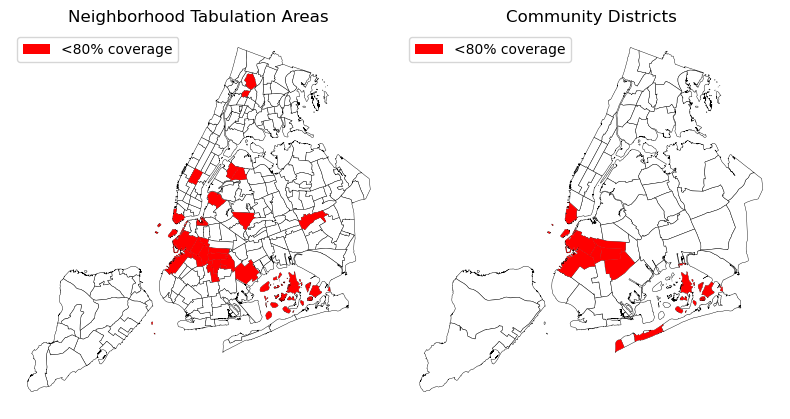

In [33]:
plot_low_coverage(nta_stats=nta_stats,cd_stats=cd_stats,nta_min=80,cd_min=80)

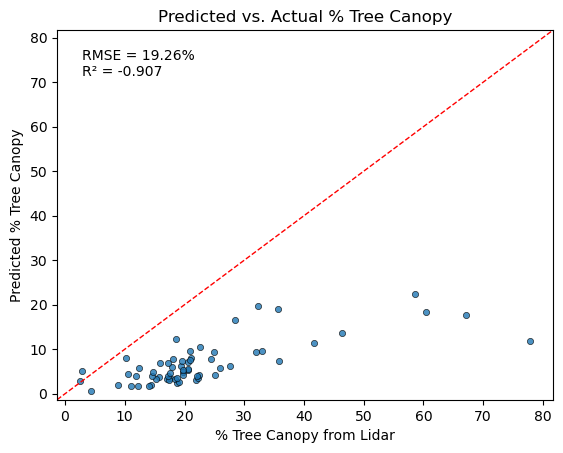

In [25]:
predicted_v_actual(cd_stats,min_coverage=0.8)

In [36]:
from matplotlib.colors import TwoSlopeNorm

def plot_residuals(gdf):
    max_abs = gdf['residual'].abs().max()
    norm = TwoSlopeNorm(vmin=-max_abs,vcenter=0,vmax=max_abs)

    fig, ax = plt.subplots(figsize=(8,8))


    gdf.plot(column='residual',ax=ax,cmap='RdBu',norm=norm,edgecolor='gray',linewidth=0.3)

    # [left, bottom, width, height] in figure coordinates (0-1)
    cax = fig.add_axes([0.25, 0.49, 0.02, 0.35])
    sm = plt.cm.ScalarMappable(cmap='RdBu', norm=norm)
    cb = fig.colorbar(sm, cax=cax)
    cb.ax.set_title('Residual\n(% Canopy)', fontsize=8, pad=6)

    ax.legend(handles=[
        Patch(facecolor='gray', edgecolor='black',label='< 80%\ncoverage')
    ], loc='upper left',bbox_to_anchor=(0.142,0.49),fontsize=8,frameon=False,handleheight=1.5,handlelength=1.5)

    gdf.loc[(gdf['coverage']<=0.8)].plot(ax=ax,color='gray',edgecolor='gray',linewidth=0.3)
    ax.set_axis_off()


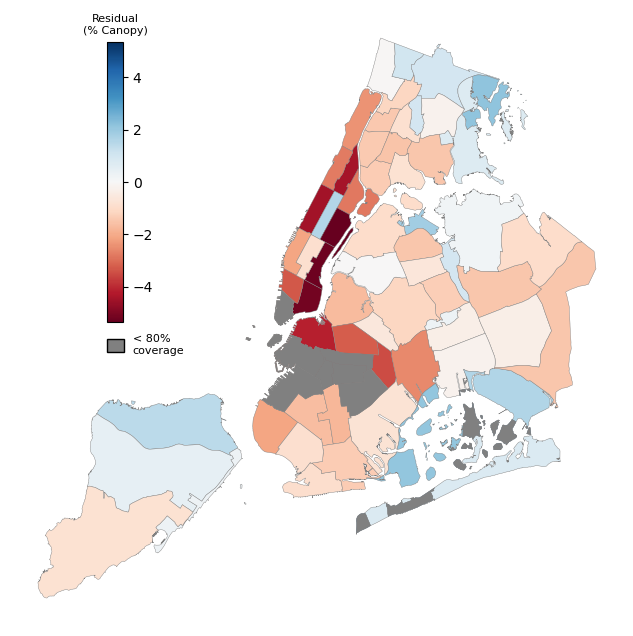

In [38]:
plot_residuals(cd_stats)

#### Year to year Change

In [103]:
def plot_change(gdf,change_col,coverage=0.8):
    max_abs = gdf.loc[gdf['coverage']>coverage,change_col].abs().max()
    norm = TwoSlopeNorm(vmin=-max_abs,vcenter=0,vmax=max_abs)

    fig, ax = plt.subplots(figsize=(8,8))


    gdf.plot(column=change_col,ax=ax,cmap='PiYG',norm=norm,edgecolor='gray',linewidth=0.3)

    # [left, bottom, width, height] in figure coordinates (0-1)
    cax = fig.add_axes([0.25, 0.49, 0.02, 0.35])
    sm = plt.cm.ScalarMappable(cmap='PiYG', norm=norm)
    cb = fig.colorbar(sm, cax=cax)
    cb.ax.set_title('Change in % Canopy)', fontsize=8, pad=6)

    ax.legend(handles=[
        Patch(facecolor='gray', edgecolor='black',label=f'< {coverage*100}%\ncoverage')
    ], loc='upper left',bbox_to_anchor=(0.142,0.49),fontsize=8,frameon=False,handleheight=1.5,handlelength=1.5)

    gdf.loc[(gdf['coverage']<=coverage)].plot(ax=ax,color='gray',edgecolor='gray',linewidth=0.3)
    ax.set_axis_off()

In [28]:
### read in nta results
nta17 = gpd.read_file(root / 'model_outputs' / 'nyc17_from_nyc17_model_nta.gpkg')
cd17 = gpd.read_file(root / 'model_outputs' / 'nyc17_from_nyc17_model_cd.gpkg')

nta21 = gpd.read_file(root / 'model_outputs' / 'nyc21_nta.gpkg')
cd21 = gpd.read_file(root / 'model_outputs' / 'nyc21_cd.gpkg')

In [29]:
nta_change = nta17.copy()

nta_change['lidar_change'] = nta21['lidar_pct'] - nta17['lidar_pct']

nta_change['pred_change'] = nta21['predicted_pct'] - nta17['predicted_pct']



In [ ]:
plot_change(nta_change,change_col='lidar_change',coverage=0.8)

In [30]:
correct_direction = np.sign(nta_change['lidar_change']) == np.sign(nta_change['pred_change'])
pct_correct = correct_direction.mean() * 100

pct_correct

# 82% of NTAs show correct direction of trend 

np.float64(81.67938931297711)

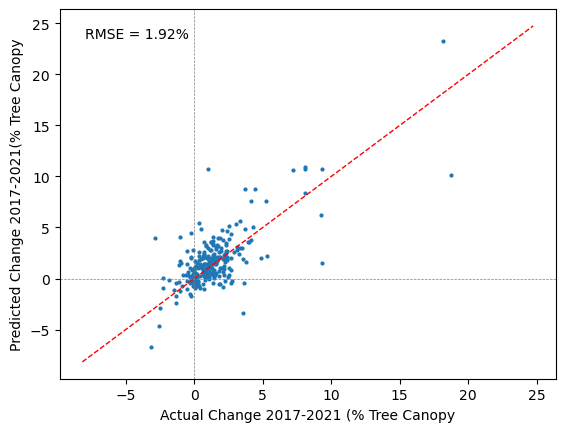

In [101]:
## actual vs predicted change
fig,ax = plt.subplots()
ax.scatter(nta_change['lidar_change'],nta_change['pred_change'],s=4)
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'r--', linewidth=1, label='1:1 line')
ax.axvline(0,linestyle='--',color='gray',linewidth=0.5)
ax.axhline(0,linestyle='--',color='gray',linewidth=0.5)
ax.set_xlabel('Actual Change 2017-2021 (% Tree Canopy')
ax.set_ylabel('Predicted Change 2017-2021(% Tree Canopy')

#ax.axvspan(-1,1,color='gray',alpha=0.3)

rmse = np.sqrt(mean_squared_error(nta_change['lidar_change'],nta_change['pred_change']))
ax.text(0.05, 0.95,
            f'RMSE = {rmse:.2f}%',
            transform=ax.transAxes,
            verticalalignment='top')
plt.show()

In [ ]:
nta_change.loc[correct_direction,'pred_change'].median()  

## actual mean change in wrong ntas = 0.30% tc (pred=0.41). actual mean change in correct ntas = 1.68% tc. (pred=2.04)
# median correct = 1.25, median incorrect = 0.006 (actual)
# median correct = 1.55, median incorrect = 0.02 (predicted)

## indicates the model is not giving super off predictions, but small changes in tree canopy (below about 1%) are within the noise of the model. 

np.float64(1.5514732188093685)

In [ ]:
nta_change['area_km2'] = nta_change.geometry.area / 10**6
nta_change.loc[~correct_direction,'area_km2'].mean() 

### mean area of correct ntas = 2.98 km2
### mean area of incorrect ntas = 3.06 km2

## size of correct and incorrect NTAs is similar

In [31]:
## establish noise/uncertainty threshold

import numpy as np

# Calculate absolute change
nta_change['abs_actual_change'] = nta_change['lidar_change'].abs()
nta_change['abs_predicted_change'] = nta_change['pred_change'].abs()

# Test different thresholds
thresholds = np.arange(0, 3.0, 0.25)

results = []
for thresh in thresholds:
    # Only evaluate NTAs where predicted change exceeds threshold
    mask = nta_change['abs_predicted_change'] >= thresh
    
    if mask.sum() < 10:  # need enough samples
        continue
    
    correct = (
        (nta_change.loc[mask, 'lidar_change'] > 0) & 
        (nta_change.loc[mask, 'pred_change'] > 0) |
        (nta_change.loc[mask, 'lidar_change'] < 0) & 
        (nta_change.loc[mask, 'pred_change'] < 0)
    )
    
    results.append({
        'threshold': thresh,
        'n_ntas': mask.sum(),
        'pct_correct': correct.mean() * 100,
        'pct_retained': mask.mean() * 100
    })

results_df = pd.DataFrame(results)
print(results_df)

    threshold  n_ntas  pct_correct  pct_retained
0        0.00     262    81.679389    100.000000
1        0.25     240    84.166667     91.603053
2        0.50     208    86.538462     79.389313
3        0.75     186    88.709677     70.992366
4        1.00     168    91.666667     64.122137
5        1.25     145    91.724138     55.343511
6        1.50     126    92.063492     48.091603
7        1.75     114    92.105263     43.511450
8        2.00      98    91.836735     37.404580
9        2.25      78    92.307692     29.770992
10       2.50      70    91.428571     26.717557
11       2.75      60    91.666667     22.900763


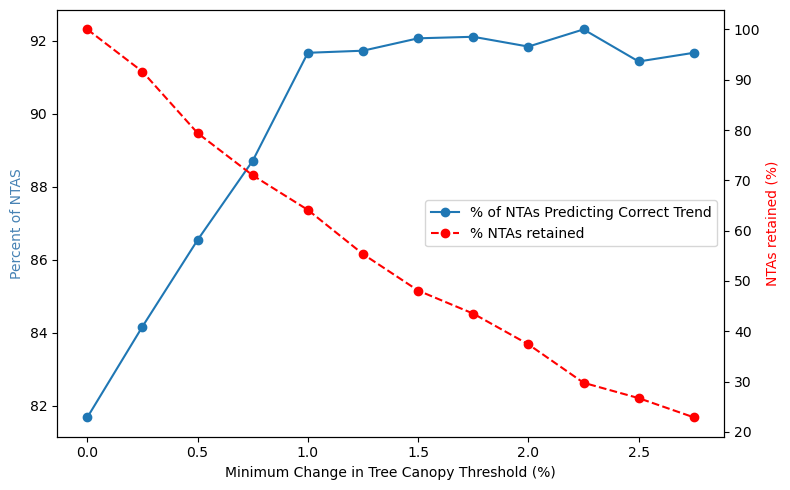

In [33]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

ax1.plot(results_df['threshold'], results_df['pct_correct'], 
         '-o', label='% of NTAs Predicting Correct Trend')
ax2.plot(results_df['threshold'], results_df['pct_retained'], 
         '--o', color='red',label='% NTAs retained')

ax1.set_xlabel('Minimum Change in Tree Canopy Threshold (%)')
ax1.set_ylabel('Percent of NTAS', color='steelblue')
ax2.set_ylabel('NTAs retained (%)', color='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.tight_layout()
plt.show()

In [ ]:
nc_2021 = xr.open_dataarray(root / 'data' / 'nyc21' / 'nyc21_bands2348_ARD.nc')

arr_2021 = xr.open_zarr(root/'data' / 'nyc21' / 'nyc_daily_raw_10m_aligned.zarr')

arr_2017 = xr.open_dataarray(root / 'data' / 'nyc17' / 'nyc17_bands2348_ARD_buffered.nc')

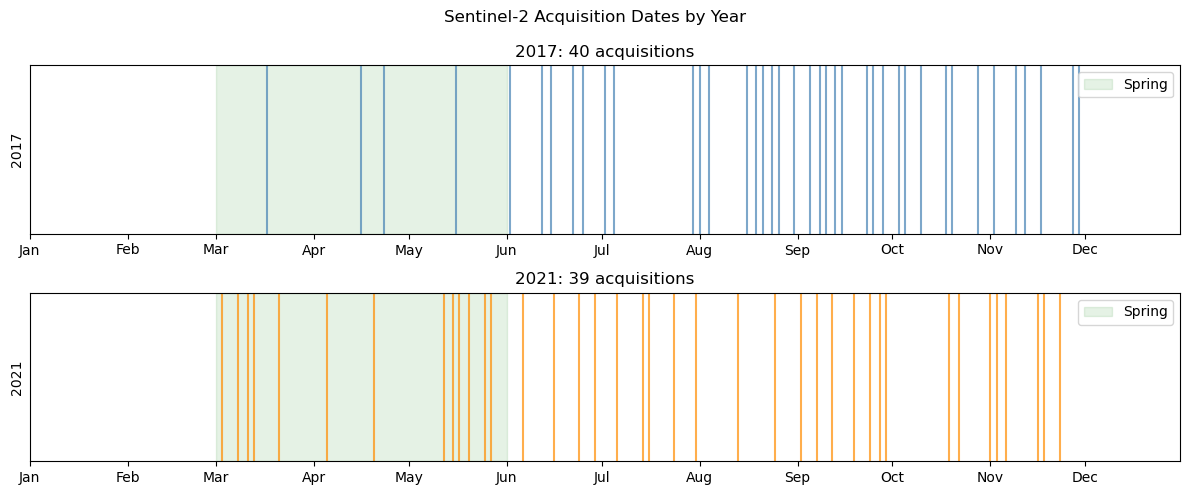

2017 acquisitions: 40
2021 acquisitions: 39
2017 spring acquisitions (Mar-May): 4
2021 spring acquisitions (Mar-May): 13


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Extract acquisition dates from both datasets
dates_2017 = pd.to_datetime(nc_2017.time.values)
dates_2021 = pd.to_datetime(nc_2021.time.values)

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=False)

for ax, dates, year, color in zip(
    axes, 
    [dates_2017, dates_2021], 
    [2017, 2021],
    ['steelblue', 'darkorange']
):
    # Plot vertical lines for each acquisition
    for date in dates:
        ax.axvline(date, color=color, alpha=0.7, linewidth=1.5)
    
    ax.set_xlim(pd.Timestamp(f'{year}-01-01'), pd.Timestamp(f'{year}-12-31'))
    ax.set_ylabel(str(year))
    ax.set_yticks([])
    
    # Add month labels
    ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))
    
    # Shade spring period
    spring_start = pd.Timestamp(f'{year}-03-01')
    spring_end = pd.Timestamp(f'{year}-06-01')
    ax.axvspan(spring_start, spring_end, alpha=0.1, color='green', label='Spring')
    
    ax.set_title(f'{year}: {len(dates)} acquisitions')
    ax.legend(loc='upper right')

plt.suptitle('Sentinel-2 Acquisition Dates by Year', fontsize=12)
plt.tight_layout()
#plt.savefig('acquisition_dates.png', dpi=150)
plt.show()

# Print summary stats
print(f"2017 Acquisition Dates")
print(f"2021 Acquisition Dates")

# Compare spring coverage specifically
for dates, year in [(dates_2017, 2017), (dates_2021, 2021)]:
    spring = dates[(dates.month >= 3) & (dates.month <= 5)]
    print(f"{year} spring acquisitions (Mar-May): {len(spring)}")